Step 1: Import Necessary Libraries & Dataset

In [1]:
# Python packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
%matplotlib inline


In [2]:
# Load Dataset

test = pd.read_csv('C:\\Users\Asus\\Documents\\Collage\\Tel-U\\UKM\\UKM Aktif 2024\\GDGOC Member 2024\\Kaggle Competition ML\\gdgoc-telu-ml-challenge\\test.csv')
train = pd.read_csv('C:\\Users\Asus\\Documents\\Collage\\Tel-U\\UKM\\UKM Aktif 2024\\GDGOC Member 2024\\Kaggle Competition ML\\gdgoc-telu-ml-challenge\\train.csv')





In [3]:
train.head()

,ID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,1,Martin,727.0,Spain,Male,38.0,2,62276.99,1,Yes,Yes,59280.79,No,4,DIAMOND,757,0
1,2,Chinweuba,529.0,France,Female,29.0,8,0.00,2,Yes,NaN,19842.11,No,3,SILVER,476,0
2,3,Clapp,589.0,France,Female,50.0,4,0.00,2,No,Yes,182076.97,No,4,PLATINUM,441,0
3,4,Boni,515.0,France,Male,40.0,0,109542.29,1,Yes,Yes,166370.81,No,5,GOLD,312,0
4,5,Jamieson,528.0,Spain,Male,43.0,7,97473.87,2,Yes,Yes,159823.16,No,3,PLATINUM,654,0


In [4]:
test.head()

,ID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,2001,Ugonna,693,Germany,Male,44,5,124601.58,2,Yes,Yes,46998.13,Yes,2,SILVER,408
1,2002,Nebeolisa,607,Germany,Male,29,7,102609.00,1,Yes,No,163257.44,No,5,DIAMOND,800
2,2003,Tsai,689,Spain,Male,73,1,108555.07,1,No,Yes,167969.15,No,1,PLATINUM,623
3,2004,Downie,660,France,Female,38,5,110570.78,2,Yes,No,195906.59,No,1,SILVER,472
4,2005,Morehead,503,France,Male,38,1,0.00,2,Yes,Yes,95153.24,No,2,DIAMOND,433


In [5]:
print(f'Train columns: {train.columns}')
print(f'Test columns: {test.columns}')

Train columns: Index(['ID', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Card Type',
       'Point Earned', 'Exited'],
      dtype='object')
Test columns: Index(['ID', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Card Type',
       'Point Earned'],
      dtype='object')


Step 2: Exploratory Data Analysis (EDA)

In [6]:
# EDA (Exploratory Data Analysis)
numerical_cols = [var for var in train.columns if train[var].dtype != 'object'] # get the numerical columns
categorical_cols = [var for var in train.columns if train[var].dtype == 'object'] # get the categorical columns

print('Numerical columns:')
print(numerical_cols)

print('Categorical columns:')
print(categorical_cols)

Numerical columns:
['ID', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'Exited']
Categorical columns:
['Surname', 'Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Complain', 'Card Type']


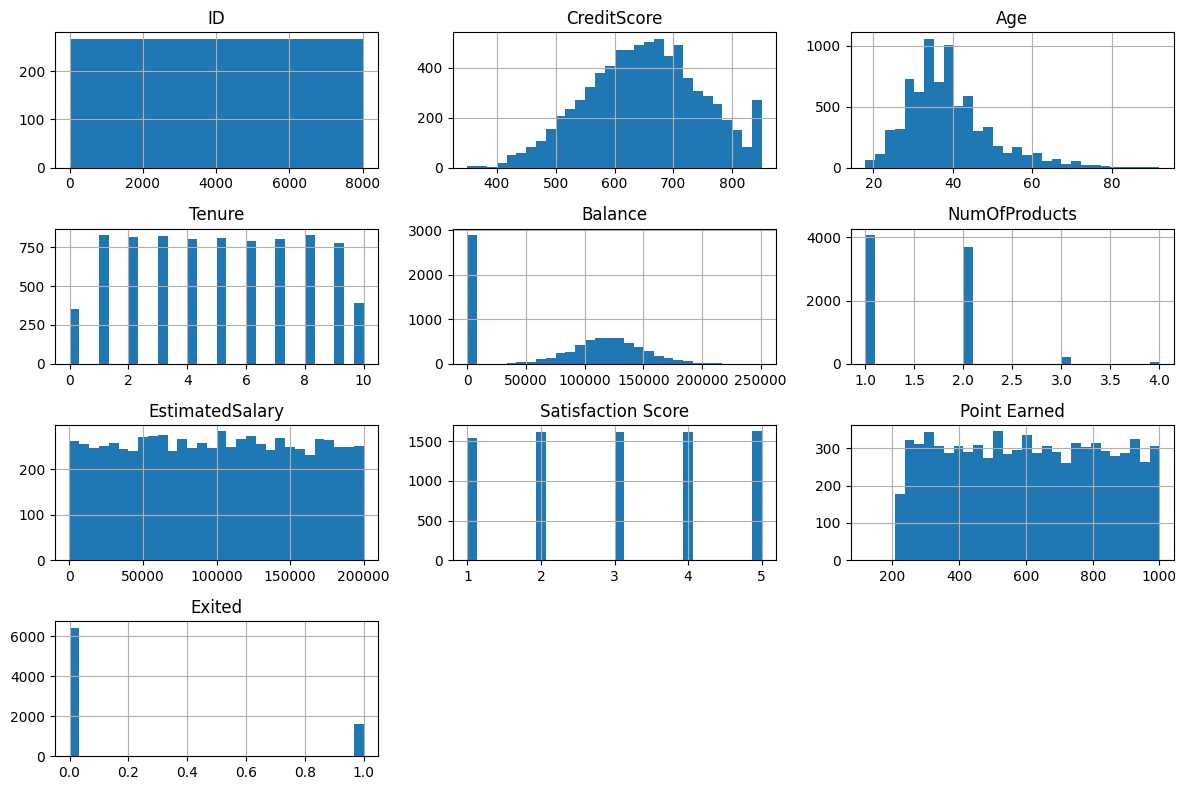

In [7]:
import matplotlib.pyplot as plt

train[numerical_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()


In [8]:
categorical_cols

['Surname',
 'Geography',
 'Gender',
 'HasCrCard',
 'IsActiveMember',
 'Complain',
 'Card Type']

In [9]:
# Removing 'Surname' from categorical_cols
x = 'Surname'

while(x in categorical_cols):
    categorical_cols.remove(x)
    
categorical_cols


['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Complain', 'Card Type']

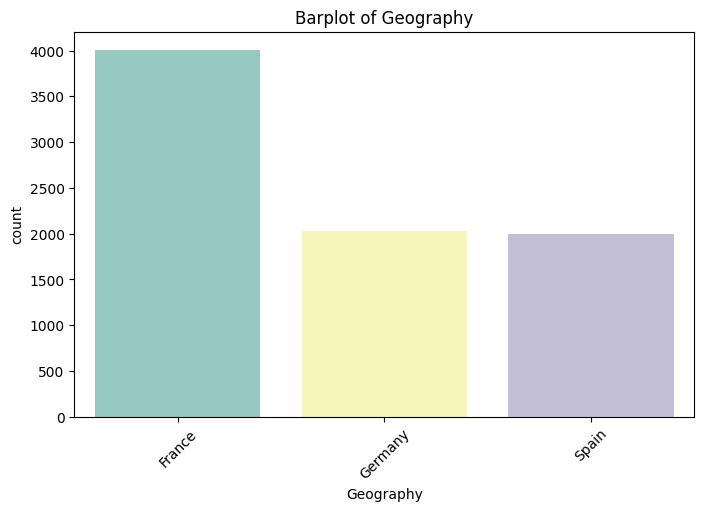

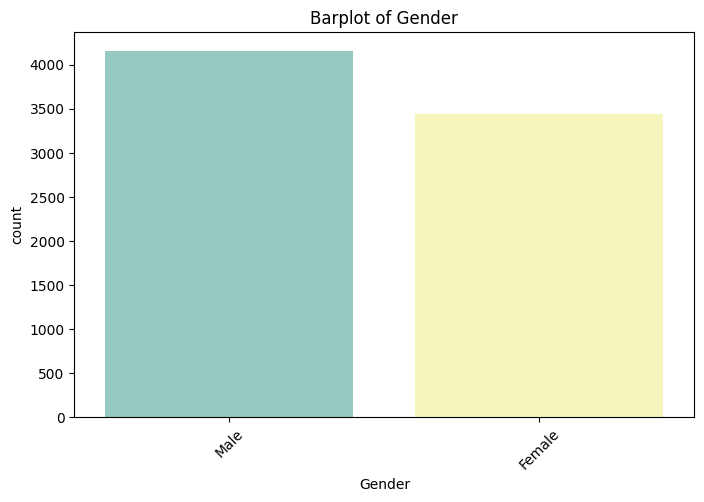

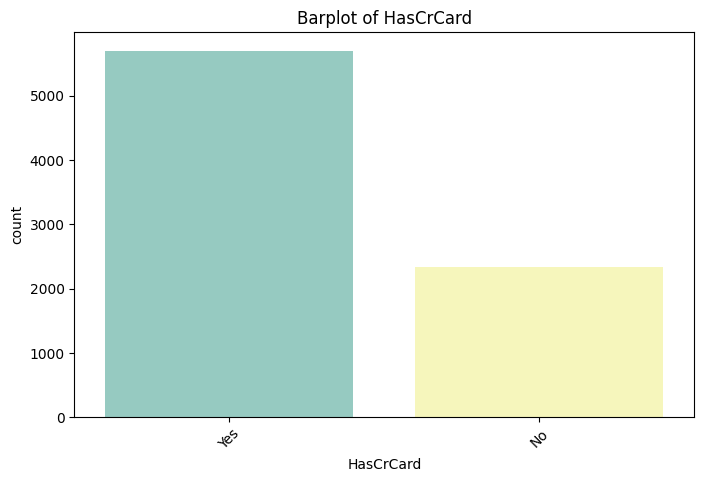

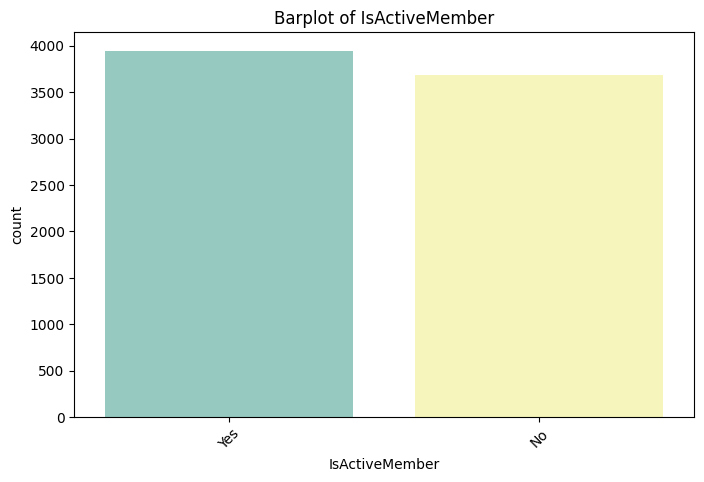

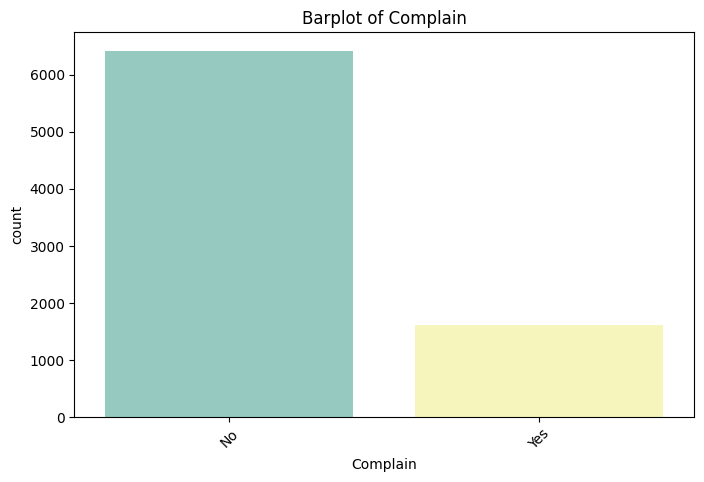

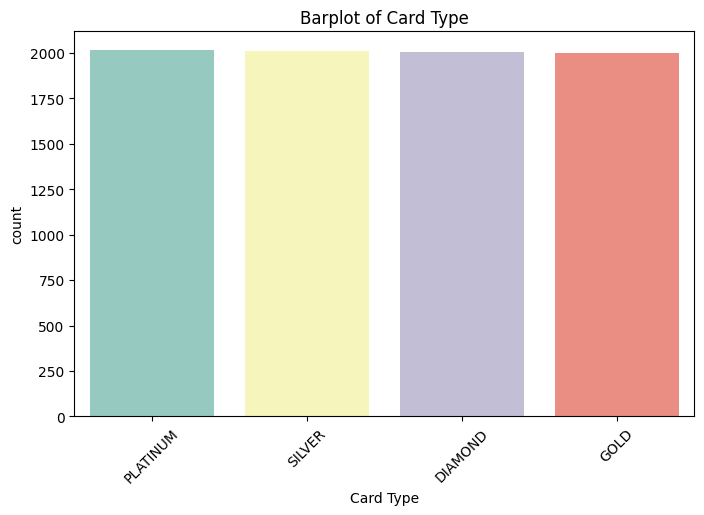

In [10]:
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=train, x=col, order=train[col].value_counts().index, palette='Set3')
    plt.title(f'Barplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [11]:
train2 = train.copy()

for col in categorical_cols :
    le = LabelEncoder()
    
    train2[col] = le.fit_transform(train2[col])
    
train2.head()

,ID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,1,Martin,727.0,2,1,38.0,2,62276.99,1,1,1,59280.79,0,4,0,757,0
1,2,Chinweuba,529.0,0,0,29.0,8,0.00,2,1,2,19842.11,0,3,3,476,0
2,3,Clapp,589.0,0,0,50.0,4,0.00,2,0,1,182076.97,0,4,2,441,0
3,4,Boni,515.0,0,1,40.0,0,109542.29,1,1,1,166370.81,0,5,1,312,0
4,5,Jamieson,528.0,2,1,43.0,7,97473.87,2,1,1,159823.16,0,3,2,654,0


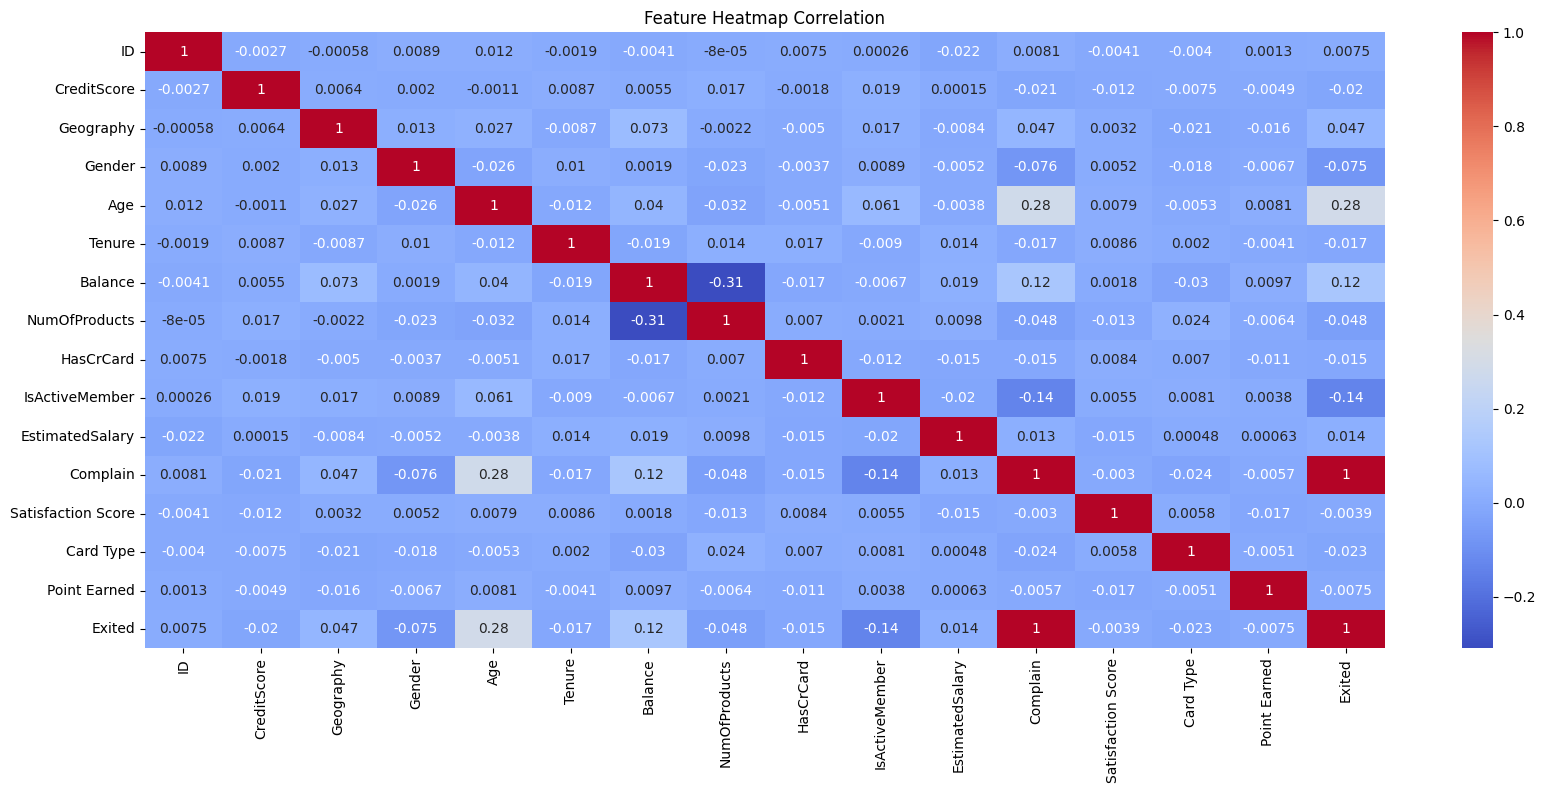

In [12]:
num_corr = train2.drop('Surname', axis=1).corr()

plt.figure(figsize=(20,8))
sns.heatmap(num_corr, annot=True, cmap='coolwarm')
plt.title('Feature Heatmap Correlation')
plt.show()


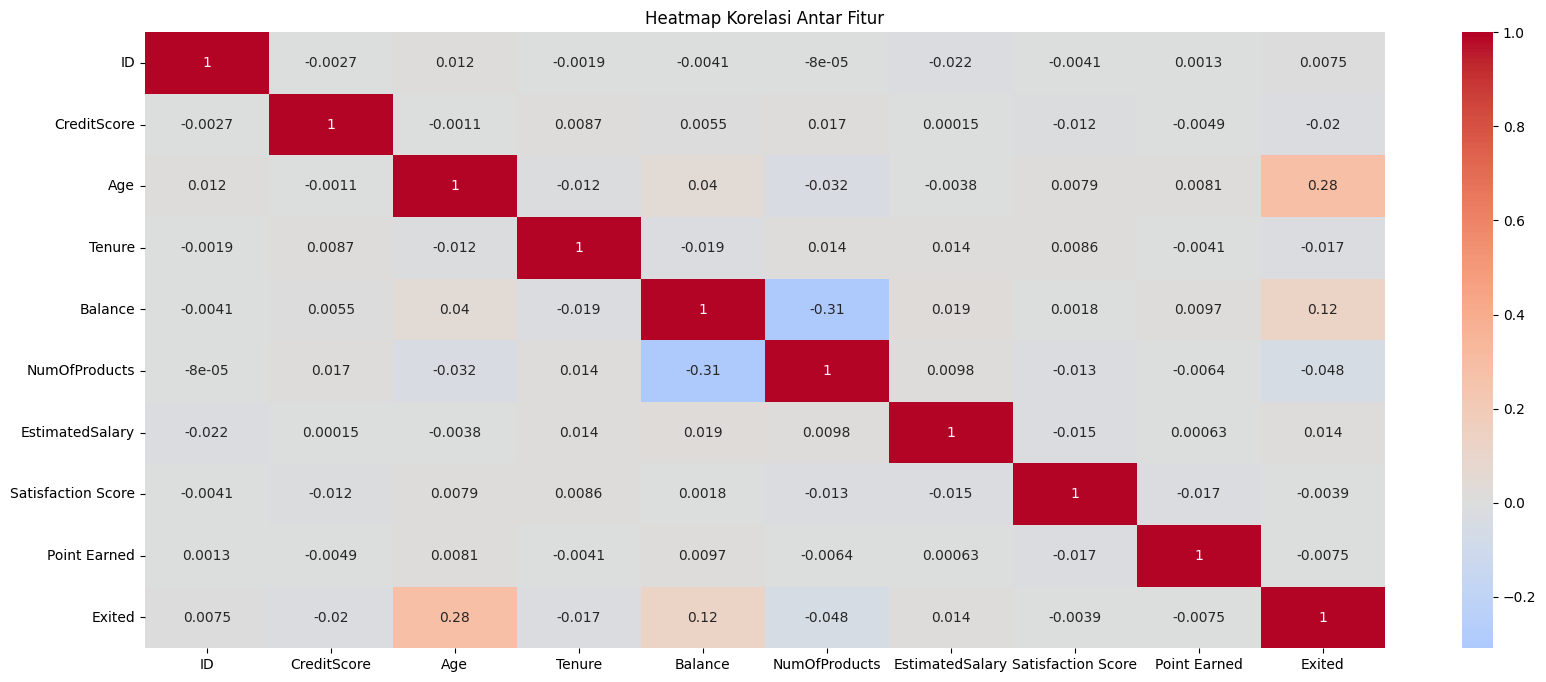

In [13]:

# Filter hanya kolom numerik
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 8))
sns.heatmap(train[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


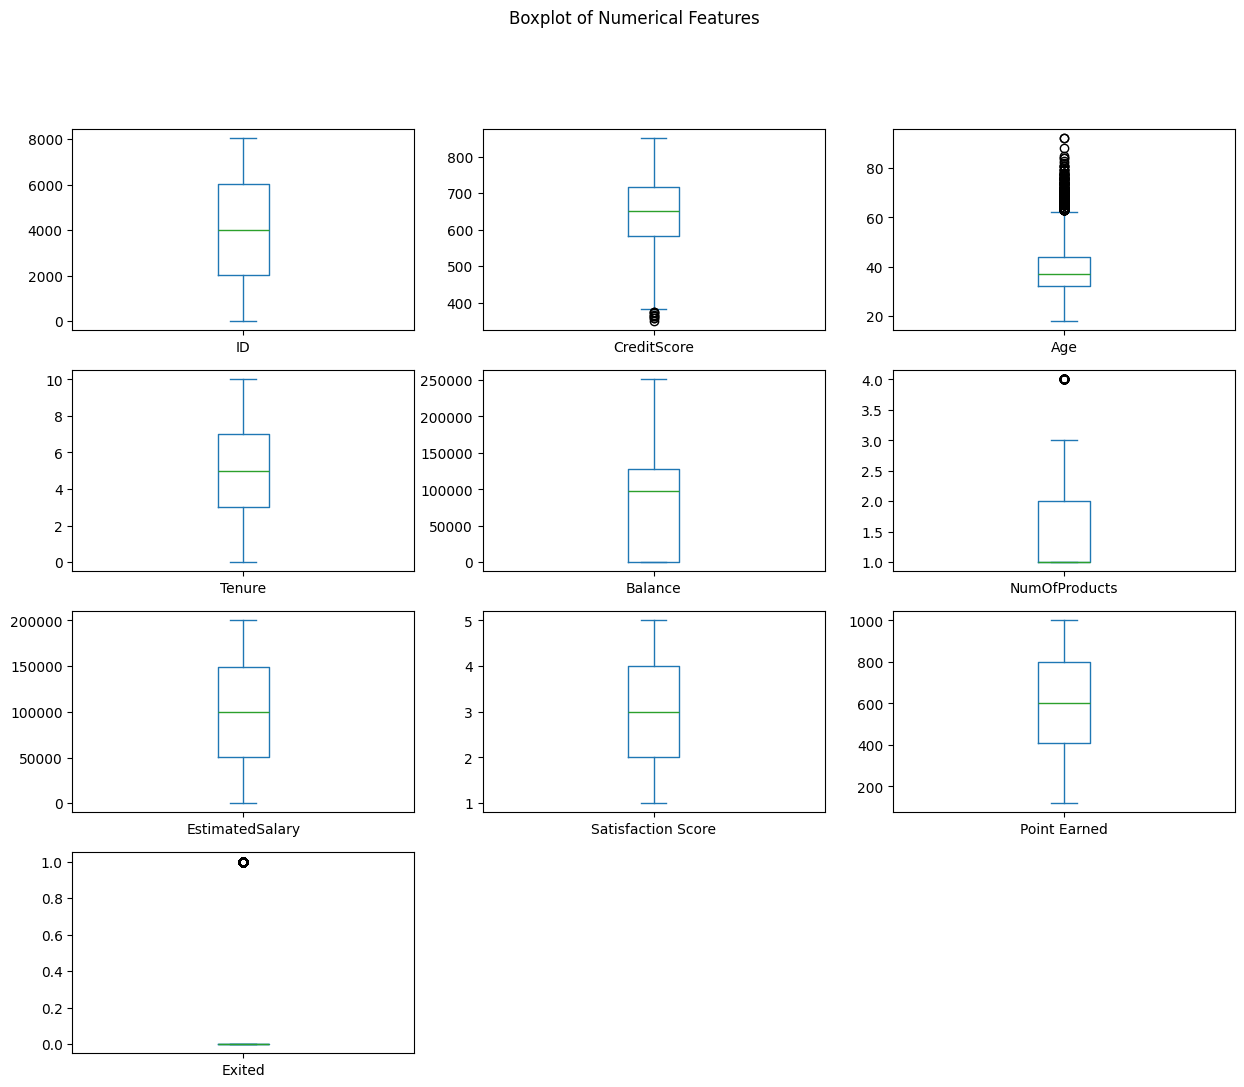

In [14]:
#numerical_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'PointEarned', 'SatisfactionScore']
train[numerical_cols].plot(kind='box', subplots=True, layout=(4, 3), figsize=(15, 12), sharex=False, sharey=False)
plt.suptitle('Boxplot of Numerical Features')
plt.show()


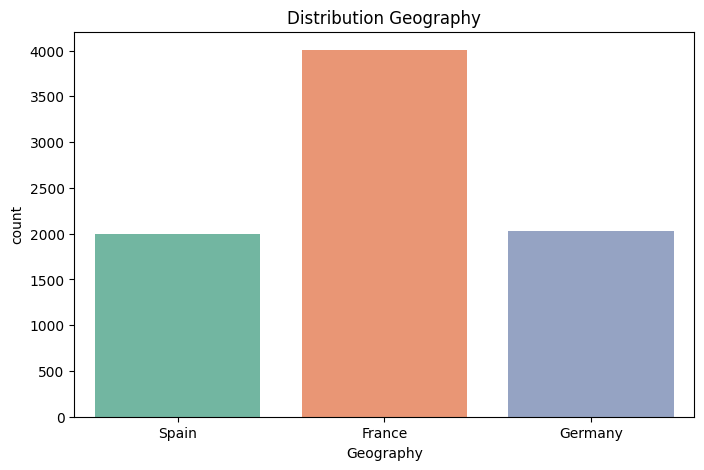

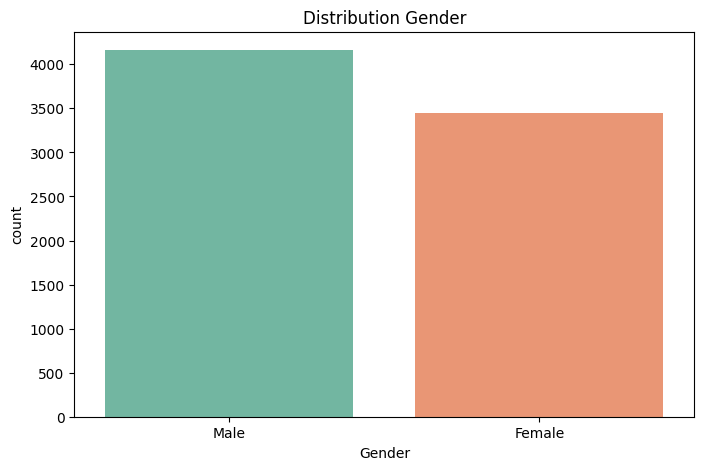

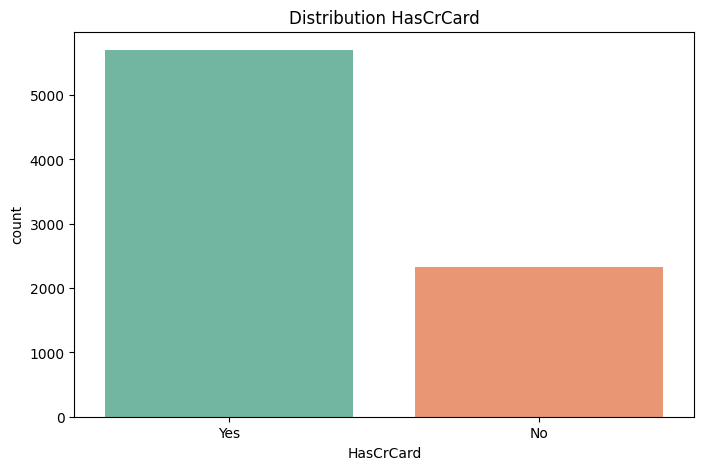

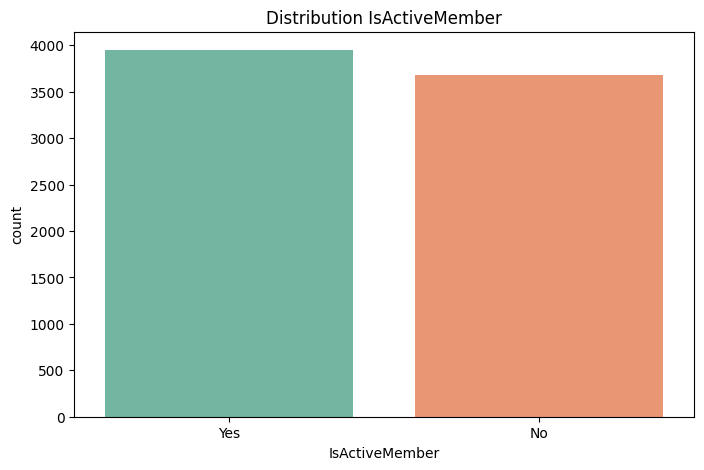

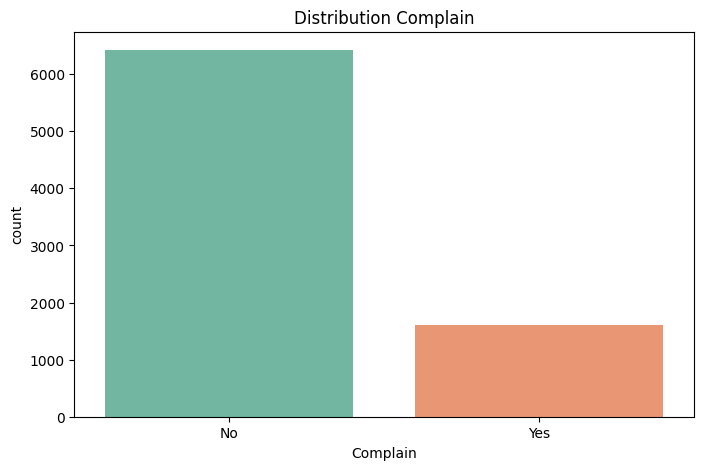

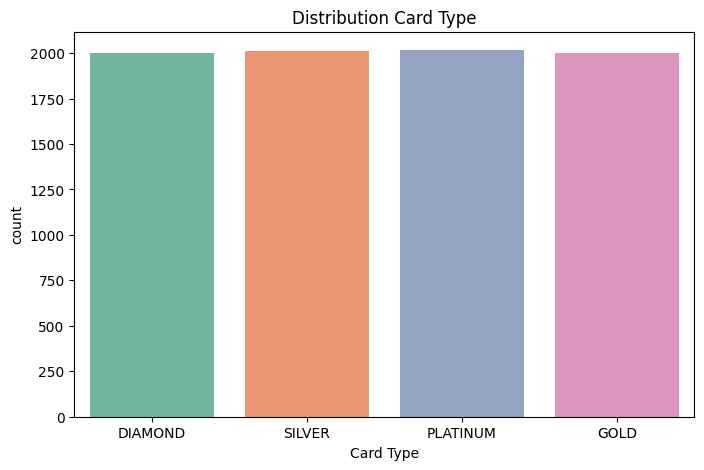

In [15]:
#categorical_cols = ['Geography', 'Gender', 'IsActiveMember']
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=train, x=col, palette='Set2')
    plt.title(f'Distribution {col}')
    plt.show()


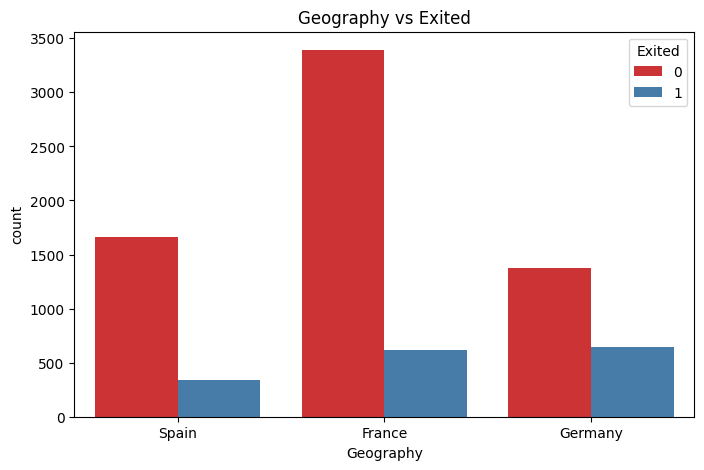

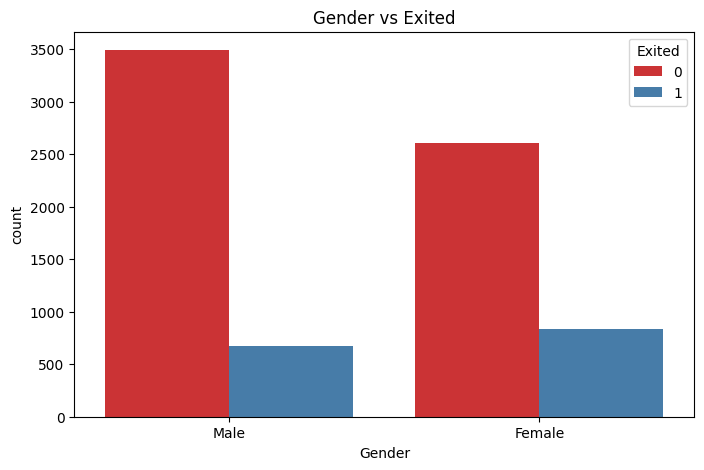

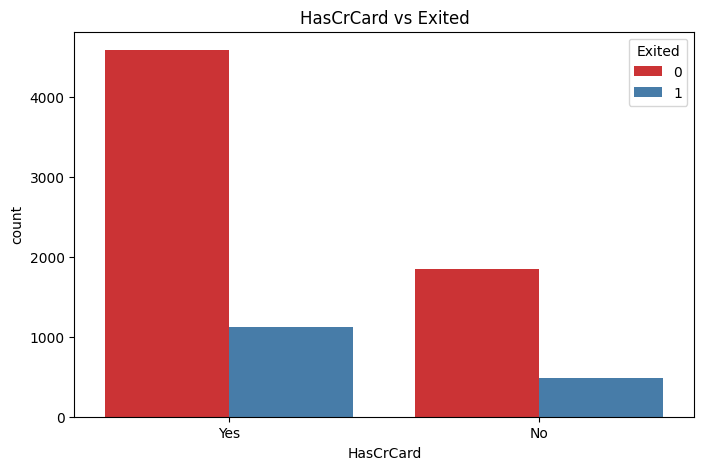

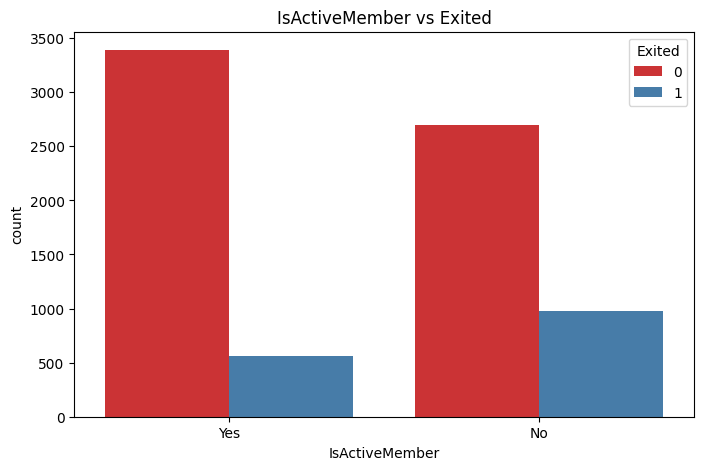

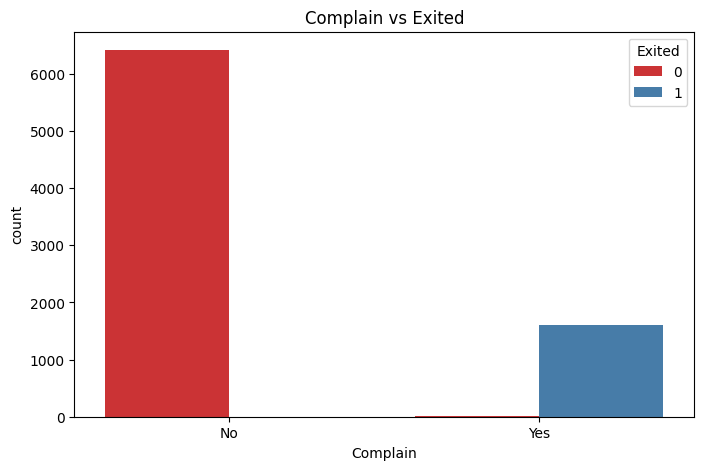

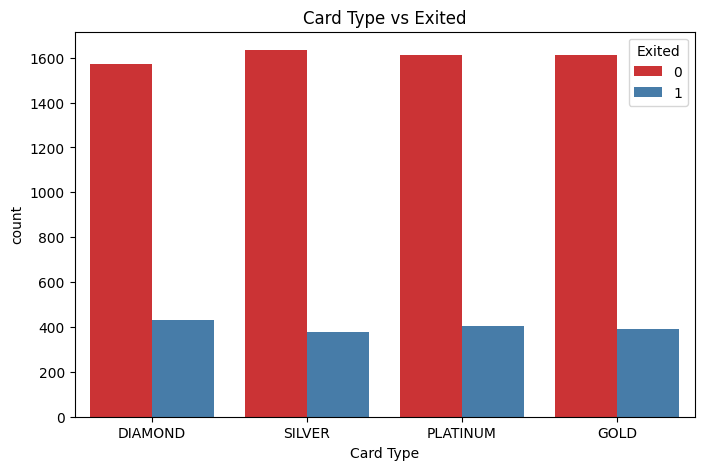

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=train, x=col, hue='Exited', palette='Set1')
    plt.title(f'{col} vs Exited')
    plt.show()


Step 3: Feature Engineering & Data Preprocessing

In [17]:
# Filling Missing Values Test (false)
test.isna().sum().sort_values(ascending=False)

ID                    0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [18]:
# Filling Missing Values Train (false)
train.isna().sum().sort_values(ascending=False)


Age                   442
CreditScore           427
Gender                423
IsActiveMember        402
EstimatedSalary       366
ID                      0
Point Earned            0
Card Type               0
Satisfaction Score      0
Complain                0
NumOfProducts           0
HasCrCard               0
Surname                 0
Balance                 0
Tenure                  0
Geography               0
Exited                  0
dtype: int64

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>, <Axes: >]],
      dtype=object)

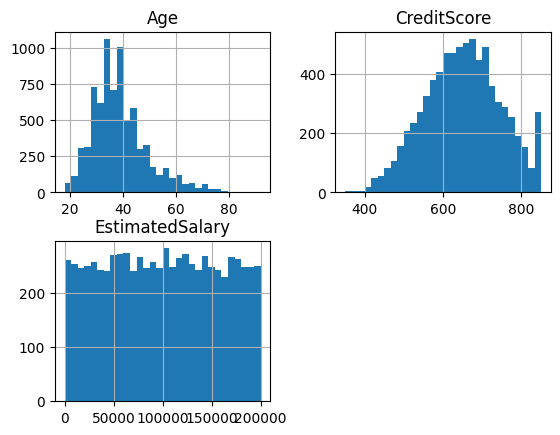

In [19]:
train[['Age', 'CreditScore','EstimatedSalary']].hist(bins=30)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>, <Axes: >]],
      dtype=object)

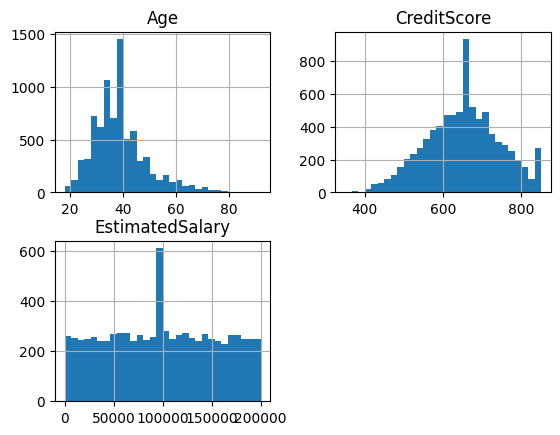

In [20]:
# Filling Missing Values
for col in ['Age', 'CreditScore', 'EstimatedSalary'] :
    train[col].fillna(train[col].mean(), inplace=True)
    
train[['Age', 'CreditScore','EstimatedSalary']].hist(bins=30)

In [21]:
train.isna().sum().sort_values(ascending=False)

Gender                423
IsActiveMember        402
ID                      0
HasCrCard               0
Point Earned            0
Card Type               0
Satisfaction Score      0
Complain                0
EstimatedSalary         0
NumOfProducts           0
Surname                 0
Balance                 0
Tenure                  0
Age                     0
Geography               0
CreditScore             0
Exited                  0
dtype: int64

In [22]:
train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
train['IsActiveMember'].fillna(train['IsActiveMember'].mode()[0], inplace=True)


In [23]:
train.isna().sum().sort_values(ascending=False)

ID                    0
HasCrCard             0
Point Earned          0
Card Type             0
Satisfaction Score    0
Complain              0
EstimatedSalary       0
IsActiveMember        0
NumOfProducts         0
Surname               0
Balance               0
Tenure                0
Age                   0
Gender                0
Geography             0
CreditScore           0
Exited                0
dtype: int64

In [24]:
train.duplicated().sum()

0

In [25]:
train.head()

,ID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,1,Martin,727.0,Spain,Male,38.0,2,62276.99,1,Yes,Yes,59280.79,No,4,DIAMOND,757,0
1,2,Chinweuba,529.0,France,Female,29.0,8,0.00,2,Yes,Yes,19842.11,No,3,SILVER,476,0
2,3,Clapp,589.0,France,Female,50.0,4,0.00,2,No,Yes,182076.97,No,4,PLATINUM,441,0
3,4,Boni,515.0,France,Male,40.0,0,109542.29,1,Yes,Yes,166370.81,No,5,GOLD,312,0
4,5,Jamieson,528.0,Spain,Male,43.0,7,97473.87,2,Yes,Yes,159823.16,No,3,PLATINUM,654,0


In [26]:
test.head()

,ID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,2001,Ugonna,693,Germany,Male,44,5,124601.58,2,Yes,Yes,46998.13,Yes,2,SILVER,408
1,2002,Nebeolisa,607,Germany,Male,29,7,102609.00,1,Yes,No,163257.44,No,5,DIAMOND,800
2,2003,Tsai,689,Spain,Male,73,1,108555.07,1,No,Yes,167969.15,No,1,PLATINUM,623
3,2004,Downie,660,France,Female,38,5,110570.78,2,Yes,No,195906.59,No,1,SILVER,472
4,2005,Morehead,503,France,Male,38,1,0.00,2,Yes,Yes,95153.24,No,2,DIAMOND,433


In [27]:
# Categorical Encoding
for col in categorical_cols :
    print(train[col].value_counts())
    print('-' *50)

Geography
France     4006
Germany    2027
Spain      1997
Name: count, dtype: int64
--------------------------------------------------
Gender
Male      4585
Female    3445
Name: count, dtype: int64
--------------------------------------------------
HasCrCard
Yes    5700
No     2330
Name: count, dtype: int64
--------------------------------------------------
IsActiveMember
Yes    4350
No     3680
Name: count, dtype: int64
--------------------------------------------------
Complain
No     6422
Yes    1608
Name: count, dtype: int64
--------------------------------------------------
Card Type
PLATINUM    2017
SILVER      2010
DIAMOND     2003
GOLD        2000
Name: count, dtype: int64
--------------------------------------------------


In [28]:
le = LabelEncoder()

for col in categorical_cols :
    le = LabelEncoder()
    
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

In [29]:
train.head()

,ID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,1,Martin,727.0,2,1,38.0,2,62276.99,1,1,1,59280.79,0,4,0,757,0
1,2,Chinweuba,529.0,0,0,29.0,8,0.00,2,1,1,19842.11,0,3,3,476,0
2,3,Clapp,589.0,0,0,50.0,4,0.00,2,0,1,182076.97,0,4,2,441,0
3,4,Boni,515.0,0,1,40.0,0,109542.29,1,1,1,166370.81,0,5,1,312,0
4,5,Jamieson,528.0,2,1,43.0,7,97473.87,2,1,1,159823.16,0,3,2,654,0


In [30]:
test.head()

,ID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,2001,Ugonna,693,1,1,44,5,124601.58,2,1,1,46998.13,1,2,3,408
1,2002,Nebeolisa,607,1,1,29,7,102609.00,1,1,0,163257.44,0,5,0,800
2,2003,Tsai,689,2,1,73,1,108555.07,1,0,1,167969.15,0,1,2,623
3,2004,Downie,660,0,0,38,5,110570.78,2,1,0,195906.59,0,1,3,472
4,2005,Morehead,503,0,1,38,1,0.00,2,1,1,95153.24,0,2,0,433


Step 4: Machine Learning Modelling

In [31]:
# Machine Learning Modelling
train.drop(['ID', 'Surname'], axis = 1, inplace= True)

X = train.drop('Exited', axis = 1)
y = train['Exited']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size = 0.2, 
    random_state= 42
)

X_train.shape, y_train.shape, X_val.shape, y_val.shape 

((6424, 14), (6424,), (1606, 14), (1606,))

*Install & Manage Numpy + CatBoost Version*

In [32]:
# Create and train CatBoostClassifier
#!pip install catboost


In [33]:
#!pip install --upgrade numpy catboost


In [34]:
#pip install --upgrade numpy


In [35]:
#!pip install --upgrade numpy catboost


In [36]:
#pip install numpy==1.23.5


In [37]:
#pip install --upgrade catboost


In [38]:
import numpy as np
import catboost

print("NumPy version:", np.__version__)
print("CatBoost version:", catboost.__version__)


NumPy version: 1.23.5
CatBoost version: 1.2.7


In [39]:
from catboost import CatBoostClassifier
#from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

model_catboost = CatBoostClassifier(
    iterations = 500,
    depth = 5,
    learning_rate = 0.1, 
    loss_function = 'Logloss',
    verbose = 100
)

model_catboost.fit(X_train, y_train)




0:	learn: 0.4197055	total: 141ms	remaining: 1m 10s
100:	learn: 0.0021057	total: 586ms	remaining: 2.31s
200:	learn: 0.0019740	total: 937ms	remaining: 1.39s
300:	learn: 0.0019734	total: 1.27s	remaining: 844ms
400:	learn: 0.0019734	total: 1.61s	remaining: 397ms
499:	learn: 0.0019729	total: 1.94s	remaining: 0us


In [40]:
y_pred = model_catboost.predict(X_train)

In [41]:
import pandas as pd

pd.Series(y_pred).value_counts()

0    5129
1    1295
Name: count, dtype: int64

In [42]:
y_val

6074    0
5958    1
3032    0
6446    0
318     0
       ..
4609    0
2943    0
2441    0
921     1
322     0
Name: Exited, Length: 1606, dtype: int64

In [43]:
y_pred_val = model_catboost.predict(X_val)

pd.Series(y_pred_val).value_counts()

0    1296
1     310
Name: count, dtype: int64

In [44]:
print(f'F1-score: {f1_score(y_val, y_pred_val)}')

F1-score: 0.9967637540453075


Step 5: Predict on Test Data


In [45]:
test.drop(['ID', 'Surname'], axis=1, inplace = True)

test.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,693,1,1,44,5,124601.58,2,1,1,46998.13,1,2,3,408
1,607,1,1,29,7,102609.00,1,1,0,163257.44,0,5,0,800
2,689,2,1,73,1,108555.07,1,0,1,167969.15,0,1,2,623
3,660,0,0,38,5,110570.78,2,1,0,195906.59,0,1,3,472
4,503,0,1,38,1,0.00,2,1,1,95153.24,0,2,0,433


In [46]:
test['Exited'] = model_catboost.predict(test)

test.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,693,1,1,44,5,124601.58,2,1,1,46998.13,1,2,3,408,1
1,607,1,1,29,7,102609.00,1,1,0,163257.44,0,5,0,800,0
2,689,2,1,73,1,108555.07,1,0,1,167969.15,0,1,2,623,0
3,660,0,0,38,5,110570.78,2,1,0,195906.59,0,1,3,472,0
4,503,0,1,38,1,0.00,2,1,1,95153.24,0,2,0,433,0


In [47]:
test['Exited'].value_counts()


Exited
0    1556
1     444
Name: count, dtype: int64

Step 6: Submission

In [48]:
submission = pd.read_csv('C:\\Users\\Asus\\Documents\\Collage\\Tel-U\\UKM\\UKM Aktif 2024\\GDGOC Member 2024\\Kaggle Competition ML\\gdgoc-telu-ml-challenge\\sample_submission.csv')

submission

,ID,Exited
0,2001,1
1,2002,0
2,2003,0
3,2004,1
4,2005,0
...,...,...
1995,3996,1
1996,3997,0
1997,3998,1
1998,3999,0


In [49]:
submission['Exited'] = test['Exited']

submission

,ID,Exited
0,2001,1
1,2002,0
2,2003,0
3,2004,0
4,2005,0
...,...,...
1995,3996,1
1996,3997,0
1997,3998,0
1998,3999,0


In [50]:
submission.to_csv('fsr_submission.csv', index=False)